## Ma solution du Travail  pratique 2-Entraînement et métriques de performance de l’apprentissage<br>

Cours : 8IAR403 – Apprentissage Machine pour les Sciences des Données

Session :Hiver 2026

Nom :DIABATE

Prénom : VAMOUSSA
***

Il faut noter que l'analyse que je m'appret a faire pour le  Travail  pratique 2 complète celle produite lors de mon travail pratique 1.
Ainsi, je vais réutiliser les mêmes approche de nettoyage et préparation des données, appliqués sous forme de pipelines de transformation ce qui me permettra de générer mon TBA.

À l’instar du travail pratique 1, le présent travail s’appuie sur un ensemble de données provenant d’un site de commerce électronique, décrivant les revenus générés par les clients.

Ce travail vise à mettre en œuvre l’étape d’entraînement d’un modèle d’apprentissage supervisé ainsi que l’évaluation rigoureuse de ses performances, conformément à la méthodologie recommandée en cours. Plus précisément, nous utiliserons l’algorithme **DecisionTreeClassifier** de scikit-learn afin de construire et comparer différents modèles.

Deux types de classeurs seront étudiés :

- Un **classeur binaire**, visant à prédire si un client génère un revenu supérieur à la moyenne.
- Un **classeur multi-classes**, permettant de discriminer trois catégories de revenus (bas, moyen, élevé).

Les modèles seront entraînés à partir du jeu d’entraînement (80 % des observations) obtenu au Travail 1, puis évalués à l’aide de 
validation croisée (k = 3 et k = 10). Les performances seront mesurées à l’aide des métriques de précision, rappel et F1-mesure. Une optimisation des hyperparamètres sera réalisée via GridSearchCV.

Enfin, les modèles retenus seront testés sur le jeu de test (20 % des observations) afin d’évaluer leur capacité de généralisation et de comparer les différents scénarios étudiés.

***
***

## Déclaration et Initialisation de mes fonctions<br>
Cette première section permet l'initialisation des paramètres essentiels au bon fonctionnement de mon projet et
définit les différentes fonctions utilisées dans le cadre de celui-ci.

### Importation des bibliothèques 
Nous débutons par l'importation des bibliothèques nécessaires pour mon projet d'apprentissage machine.
Les bibliothèques utilisées sont:

**1.pandas**, permettant l'importation et la gestion des ensembles de données nécessaires au projet.

**2.numpy**, permettant les manipulations, évaluations et fonctions mathématiques avancées sur les données.

**3.os**, permettant la gestion d'emplacement des fichiers.

**4.matplotlyb**, pour les éléments de visualisation.

**5.sklearn**, pour plusieurs opérations de traitement, mises à l'échelle et de transformation dans un contexte de ML.

## Initialisation et déclaration des fonctions<br>
Cette première section permet l'initialisation des paramètres essentiels au bon fonctionnement de mon projet et
définit les différentes fonctions utilisées dans le cadre de celui-ci.

### Importation des bibliothèques pour l'exécution d'un projet d'apprentissage machine

Nous débutons par l'importation des bibliothèques nécessaires pour mon projet d'apprentissage machine.
Les bibliothèques utilisées sont:
1. __pandas__, permettant l'importation et la gestion des ensembles de données nécessaires au projet.
2. __numpy__, permettant les manipulations, évaluations et fonctions mathématiques avancées sur les données.
3. __os__, permettant la gestion d'emplacement des fichiers.
4. __matplotlyb__, pour les éléments de visualisation.
5. __sklearn__, pour plusieurs opérations de traitement, mises à l'échelle et de transformation dans un contexte de ML.

In [136]:
# Importation des bibliothèques
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import *
from sklearn.compose import *
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, recall_score, precision_score, f1_score, make_scorer, roc_curve, auc, accuracy_score
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
pd.options.mode.chained_assignment = None

***
***
### Paramètres utilisateurs

Afin d’assurer la reproductibilité et la flexibilité des expériences menées
dans ce travail pratique, les principaux paramètres sont centralisés dans
cette section. Ils comprennent les chemins et noms des jeux de données, le
ratio de séparation entre les ensembles d’entraînement et de test, ainsi que
la graine aléatoire fixée pour garantir une répartition identique des données
à chaque exécution.

In [137]:
# --------------------------------------
# 1. Définition de mes chemins d'accès
# -------------------------------------

# Dossier contenant les fichiers CSV
filepath_dataset = "Datasets"

# Noms des fichiers utilisés dans l'étude de cas
filename_customer = "Customer.csv"              # Dataset principal contenant les clients
filename_country_pop = "CountryPopulation.csv"  # Dataset contenant les informations de population par pays
filename_country_gdp = "CountryGDP.csv"         # Dataset contenant les informations de PIB par pays

# ----------------------------------------
# 2. Paramètres de division des données
# ----------------------------------------

# Proportion du dataset réservée pour le test (20%), les 80% seront utilisés pour l'entraînement
test_train_ratio = 0.2

# Graine aléatoire (seed) pour garantir la reproductibilité, Permet d'obtenir exactement la même séparation train/test à chaque exécution
random_state_seed = 42

# ---------------------------------------
# 3. Paramètres de fusion des datasets
# ---------------------------------------

# Variable de contrôle pour décider si on utilise uniquement le dataset Customer Si "oui" alors pas de jointure
sans_merge = False

# Variable permettant d'inclure ou non le PIB dans la jointure, si "non" on ne fusionne pas avec CountryGDP
merge_gdp = False

***
***
### Préparation de la TBA

La présente analyse complète celle produite lors du travail pratique #1. Ainsi, je réutilise
les mêmes approches de nettoyage et préparation des données, appliqués sous forme de pipelines de transformation permettant
de générer mon TBA. Afin d'accélérer l'exécution, cette étape de préparation de la TBA détaille chacune des fonctions
uniquement sous forme de commentaires dans le code.

In [138]:
# Fonction de bornage des données aberrantes (outliers)
def nettoyageOutliers(df: pd.DataFrame) -> pd.DataFrame:
    # On récupère les colonnes du DataFrame (ici on veut traiter toutes les colonnes fournies)
    cols = df.columns

    # -------------------------------------
    # Méthode IQR (InterQuartile Range)
    # -------------------------------------
    
    # Q25 = 1er quartile (Q1) : 25% des valeurs sont en-dessous
    Q25 = df[cols].quantile(0.25)
    
    # Q75 = 3e quartile (Q3) : 75% des valeurs sont en-dessous
    Q75 = df[cols].quantile(0.75)

    # IQR = Q3 - Q1 : étendue interquartile (zone "normale" où se trouve le coeur des données)
    IQR = Q75 - Q25

    # -----------------------------------------------
    # Calcul des bornes (règle classique 1.5 * IQR)
    # -----------------------------------------------
    
    # Toute valeur < (Q1 - 1.5*IQR) est considérée comme outlier bas
    SeuilMin = (Q25 - 1.5 * IQR)

    # Toute valeur > (Q3 + 1.5*IQR) est considérée comme outlier haut
    SeuilMax = (Q75 + 1.5 * IQR)

    # -------------------------------
    # Bornage (clipping)
    # -------------------------------
    
    #Au lieu de supprimer les outliers, je les ramène à la borne la plus proche. 
    #Cela limite leur influence sur l'entraînement (variance, instabilité de mon modèle).
    nouv_df = df[cols].clip(SeuilMin[cols], SeuilMax[cols], axis=1)
    return nouv_df

#Je Wrappe pour que la fonction soit compatible avec FunctionTransformer
# (FunctionTransformer passe souvent un array-like, donc je recaste en DataFrame)
def bornage(data):
    return nettoyageOutliers(pd.DataFrame(data))


# Fonction de concaténation (merge) des ensembles de données
def mergeDataset(data: pd.DataFrame, pop=False, pib=False):
    # Cette fonction enrichit mon dataset "Customer" selon le scénario choisi :
    # - Sans jointure : Customer seulement
    # - Avec population : Customer + CountryPopulation
    # - Avec PIB : Customer + CountryPopulation + CountryGDP

    if pop == True:
        # Scénario où on ne fait aucune jointure (dataset Customer uniquement)
        return data
    
    # Jointure du dataset client avec les informations pays/population (data_pays)
    data_enrichie = pd.merge(data, data_pays)

    if pib == True:
        # Si demandé, on ajoute ensuite le PIB via une jointure avec data_pib
        data_enrichie = data_enrichie.merge(data_pib)

    return data_enrichie


#Fonction de conversion de caractéristiques au format numérique
def toNum(data: pd.DataFrame):
    # Conversion explicite d'une colonne en numérique
    # ce qui sera utile si la colonne est lue comme texte (object) et doit être traitée comme variable continue
    data['first_item_prize'] = pd.to_numeric(data['first_item_prize'])
    return data


# Pipeline de traitement des données numériques
num_transformer = Pipeline([
    # 1) Conversion de types (ex: texte vers numérique)
     ('toNum', FunctionTransformer(toNum, validate=False)),
    # 2) Gestion des valeurs manquantes : je remplace les NaN par la médiane (robuste aux valeurs extrêmes)
    ('imputer', SimpleImputer(strategy="median")),

    # 3) Traitement des outliers : je borne les valeurs extrêmes selon la règle IQR (clipping)
    ('clamp', FunctionTransformer(bornage, validate=False))
])


#Pipeline de traitement des données catégorielles
cat_transformer = Pipeline([
    # Encodage one-hot des variables catégorielles :
    # -je  transforme chaque catégorie en colonne binaire
    # - j'ignore les catégories inconnues au moment du test (c'est important pour éviter les erreurs)
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#Pipeline de tranformation des données numériques et catégorielles
preparationData = ColumnTransformer(
    transformers=[
        # J'applique le pipeline numérique sur toutes les colonnes de type numérique
        ('num', num_transformer, make_column_selector(dtype_include=np.number)),
        
        # J'applique le pipeline catégoriel sur toutes les colonnes non-numériques
        ('cat', cat_transformer, make_column_selector(dtype_exclude=np.number))
    ]
)


### Pipeline complet
full_pipeline = Pipeline([
    # 1) J'enrichissement des données (merge) selon le scénario choisi, kw_args permet de piloter le scénario à l'exécution via sans_merge et merge_gdp
    ('merge', FunctionTransformer(
        mergeDataset,
        kw_args={"pop": sans_merge, "pib": merge_gdp},
        validate=False
    )),

    # 2) je préparation : imputation + encodage + bornage, séparés selon num/cat
    ('preparation', preparationData),

    # 3) Standardisation :
    # je met toutes les features sur une échelle comparable (moyenne 0, écart-type 1)
    # j'utile pour certains modèles et pour stabiliser l'apprentissage
    ('standard_scaler', StandardScaler())
])

***

### Chargement des ensembles de données

Je procède au chargement des trois ensembles de données nécessaires à l’étude de cas :

**Customer**, contenant les caractéristiques individuelles des clients ;

**CountryPopulation**, contenant les informations démographiques par pays ;

**CountryGDP**, contenant les indicateurs économiques (PIB par habitant).

Lors de l’importation, je spécifie que les valeurs '?' et 'unknown' doivent être interprétées comme des valeurs manquantes (NaN). Cette décision est essentielle afin d’assurer une gestion cohérente des données incomplètes dans les étapes ultérieures du pipeline, notamment lors de l’imputation.

Je veille également à harmoniser les noms des colonnes, en particulier la colonne clé country, afin de garantir la cohérence des opérations de jointure (merge). Cette standardisation évite les ambiguïtés structurelles et assure l’intégrité des données lors de l’enrichissement du dataset principal.

Cette étape constitue une phase critique de préparation, car une mauvaise structuration des données en amont pourrait compromettre la qualité de l’apprentissage et biaiser les performances des modèles entraînés.

In [139]:
# -------------------------------
# Importation des données
# -------------------------------

# J'importe le dataset principal contenant les informations des clients.
# Je précise que les valeurs '?' et 'unknown' doivent être interprétées comme des valeurs manquantes (NaN).
data_client = pd.read_csv(
    os.path.join(filepath_dataset, filename_customer),
    na_values=['?', 'unknown']
)


# J'importe le dataset contenant les informations de population par pays.
# De la même manière, je traite '?' et 'unknown' comme des valeurs manquantes.
data_pays = pd.read_csv(
    os.path.join(filepath_dataset, filename_country_pop),
    na_values=['?', 'unknown']
)

# Je renomme les colonnes pour assurer la cohérence lors des jointures (merge).
# Je m'assure que la colonne servant de clé de jointure s'appelle "country".
data_pays.columns = ['country', 'population']


# J'importe le dataset contenant le PIB par pays.
data_pib = pd.read_csv(
    os.path.join(filepath_dataset, filename_country_gdp),
    na_values=['?', 'unknown']
)

# Je renomme également les colonnes afin d'assurer une cohérence avec les autres datasets.
# La colonne GDP_inhab représente le PIB par habitant.
data_pib.columns = ['country', 'GDP_inhab']
data_pib.columns

Index(['country', 'GDP_inhab'], dtype='object')

***

### Séparation de données d'entraînement et d'évaluation

Afin d’éviter toute forme de biais dans l’évaluation du modèle, je procède immédiatement à la séparation du jeu de données en deux sous-ensembles distincts : un ensemble d’entraînement et un ensemble de test.

Cette étape est essentielle en apprentissage supervisé, car elle permet d’entraîner le modèle sur une partie des données, tout en conservant un échantillon indépendant destiné à mesurer sa capacité de généralisation.

En isolant dès le départ le jeu de test, je m’assure que les performances finales ne sont pas influencées par des informations déjà utilisées lors de l’apprentissage. Cela garantit une évaluation plus fiable et conforme à la méthodologie recommandée en cours.

In [140]:
# ------------------------------------
# Division des ensembles de données
# ------------------------------------

# Je sépare le dataset original en deux sous-ensembles :
# - un ensemble d'entraînement (80%)
# - un ensemble de test (20%)
# Cette séparation respecte la méthodologie vue en cours.
train_set, test_set = train_test_split(
    data_client,
    test_size=test_train_ratio,
    random_state=random_state_seed
)

# -------------------------------
# Vérification des dimensions
# -------------------------------

# Je vérifie la taille du dataset original,
# puis celle des ensembles d'entraînement et de test,
# afin de m'assurer que la séparation a été effectuée correctement.
print("Taille de l'ensemble de données original:\n", data_client.shape)
print("Taille de l'ensemble de données d'entraînement:\n", train_set.shape)
print("Taille de l'ensemble de données d'évaluation:\n", test_set.shape)


# ----------------------------------------------------------
# Traitement des valeurs manquantes dans la variable cible
# ----------------------------------------------------------

# Comme la variable cible "revenue" sera retirée du dataset avant le passage dans le pipeline,
# je traite directement ses valeurs manquantes ici.

# Je remplace les valeurs manquantes de revenue dans le jeu d'entraînement
# par la médiane calculée sur ce même jeu.
train_set["revenue"].replace(
    np.nan,
    train_set["revenue"].median(),
    inplace=True
)

# Je fais la même opération pour le jeu de test,
# en utilisant la médiane propre au jeu de test.
test_set["revenue"].replace(
    np.nan,
    test_set["revenue"].median(),
    inplace=True
)

Taille de l'ensemble de données original:
 (10000, 8)
Taille de l'ensemble de données d'entraînement:
 (8000, 8)
Taille de l'ensemble de données d'évaluation:
 (2000, 8)


C:\Users\Vamssy\AppData\Local\Temp\ipykernel_6316\1241666842.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_set["revenue"].replace(
C:\Users\Vamssy\AppData\Local\Temp\ipykernel_6316\1241666842.py:44: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 

***
***
### Question 2.1 - Entraînement d’un classeur binaire

Dans un premier temps, je souhaite créer un classeur binaire dont la variable cible est le revenu. Il s’agit de prédire
si un client est susceptible ou non de générer plus de revenus que la moyenne.


### Question 2.1.1 - Transformation binaire de la variable "_revenue_"

Je dois écrire une fonction permettant de remplacer la valeur de la variable "_revenue_" par rapport à la moyenne par:
* Valeur 1: _Revenue_ supérieur à la moyenne
* Valeur 0: _Revenue_ inférieur ou égal à la moyenne.

In [141]:
# --------------------------------------------------------
# Fonction de transformation binaire de la variable cible
# --------------------------------------------------------

def binarize_att(data: pd.DataFrame, att_name):
    
    # Je calcule la moyenne de la variable cible (ici "revenue")
    att_mean = data[att_name].mean()
    
    # Je transforme la variable continue en variable binaire :
    # - 1 si la valeur est strictement supérieure à la moyenne
    # - 0 sinon (valeur inférieure ou égale à la moyenne)
    data[att_name] = np.where(data[att_name] > att_mean, 1, 0)
    
    return data


# ------------------------------------------------------------
# Application de la transformation sur les jeux train et test
# ------------------------------------------------------------

# Je crée une copie du jeu d'entraînement pour éviter de modifier l'original
train_set_bin = binarize_att(train_set.copy(), "revenue")

# Je fais la même transformation sur le jeu de test
test_set_bin = binarize_att(test_set.copy(), "revenue")


# --------------------------------------------
# Vérification de la distribution des classes
# --------------------------------------------

print("Distribution du revenue en fonction de la moyenne:")
print("0: Plus petit ou égal, 1: Plus grand que la moyenne")

# J'affiche le nombre d'observations dans chaque classe
print(train_set_bin["revenue"].value_counts())

Distribution du revenue en fonction de la moyenne:
0: Plus petit ou égal, 1: Plus grand que la moyenne
revenue
0    4865
1    3135
Name: count, dtype: int64


### Analyse de la distribution des classes

Après transformation de la variable revenue en variable binaire, j’obtiens la distribution suivante dans le jeu d’entraînement :

4865 observations appartiennent à la classe 0 (revenu inférieur ou égal à la moyenne) ;

3135 observations appartiennent à la classe 1 (revenu supérieur à la moyenne).

J'observe donc un léger déséquilibre entre les deux classes, la classe 0 étant majoritaire.

### Interprétation

Ce déséquilibre reste modéré (environ 60 % / 40 %), ce qui signifie :

le problème de classification n’est pas fortement déséquilibré ;

les métriques comme la précision, le rappel et la F1-mesure restent pertinentes ;

il n’est pas nécessaire, à ce stade, d’appliquer des techniques spécifiques de rééquilibrage (comme le suréchantillonnage ou le sous-échantillonnage).

Cependant, lors de l’analyse des performances, je porterai une attention particulière au rappel et à la F1-mesure afin de m’assurer que le modèle ne favorise pas excessivement la classe majoritaire.

***

***

### Retrait de l'attribut de classification "_revenue_"

Afin d’entraîner un modèle de classification binaire, je retire la variable cible revenue de l’ensemble des variables explicatives. Cette séparation est nécessaire, car le modèle doit apprendre à prédire cette variable uniquement à partir des autres caractéristiques disponibles.

Je conserve néanmoins les valeurs de revenue dans les variables Y_train et Y_test, qui serviront respectivement :

**à guider l’apprentissage du modèle sur les données d’entraînement ;**

**à évaluer ses performances sur des données indépendantes.**

Cette démarche me permet d’éviter toute fuite d’information (data leakage) et garantit une évaluation rigoureuse de la capacité du modèle à généraliser.

In [142]:
# ----------------------------------------------------------------------
# Séparation des variables explicatives et de la variable cible (Train)
# ----------------------------------------------------------------------

# Je retire la variable cible "revenue" de l'ensemble d'entraînement
# afin d'obtenir uniquement les variables explicatives (features).
X_train = train_set_bin.drop(['revenue'], axis=1)

# Je conserve la variable cible dans un vecteur séparé.
Y_train = train_set_bin['revenue']


# ---------------------------------------------------------------------
# Séparation des variables explicatives et de la variable cible (Test)
# ---------------------------------------------------------------------

# Je fais la même séparation pour le jeu de test.
X_test = test_set_bin.drop(['revenue'], axis=1)
Y_test = test_set_bin['revenue']

***

### Application des pipelines

Une fois les données préparées et la variable de classification revenue retirée, j’applique les différents pipelines configurés lors de l’étape de préparation de la TBA (Table de Base d’Apprentissage).

Ces pipelines permettent :

d’enrichir les données selon le scénario choisi (Customer seul, Customer + Population, Customer + Population + PIB) ;

de traiter automatiquement les variables numériques et catégorielles ;

d’appliquer l’imputation, le bornage des valeurs aberrantes, l’encodage et la normalisation ;

d’obtenir une représentation finale des données prête pour l’entraînement des modèles.

Cette étape garantit que toutes les transformations sont réalisées de manière cohérente, reproductible et sans fuite d’information, conformément à la méthodologie recommandée en apprentissage automatique.

En appliquant ces pipelines sur les ensembles d’entraînement et de test, je m’assure que les données sont transformées selon les mêmes règles, ce qui permet une évaluation fiable des performances du modèle.

In [143]:
# -------------------------------------------------------
# Scénario 1 : considérer uniquement le dataset Customer
# -------------------------------------------------------

# Je configure le pipeline pour ne faire aucune jointure (pas de Population, pas de PIB).
# L’objectif est d’entraîner un modèle uniquement avec les variables du dataset Customer.
sans_merge = True

# J'applique le pipeline complet sur les données d'entraînement et de test.
# Le résultat est une matrice de caractéristiques prête pour l'apprentissage.
X_train_nopop = full_pipeline.fit_transform(X_train)
X_test_nopop = full_pipeline.fit_transform(X_test)
X_test_nopop

# -----------------------------------------------
# Scénario 2 : Customer + Population (sans PIB)
# ----------------------------------------------

# Je configure le pipeline pour inclure la jointure avec la Population,
# mais sans ajouter les informations de PIB.
merge_gdp = False

# J'applique à nouveau le pipeline afin d’obtenir une nouvelle représentation des données
# enrichie par la variable population.
X_train_nogdp = full_pipeline.fit_transform(X_train)
X_test_nogdp = full_pipeline.fit_transform(X_test)
X_test_nogdp

# -----------------------------------------
# Scénario 3 : Customer + Population + PIB
# -----------------------------------------

# Je configure le pipeline pour inclure également le dataset PIB.
# Cette configuration correspond au scénario le plus enrichi en variables pays.
merge_gdp = True

# J'applique le pipeline complet afin d'obtenir la version enrichie par population + PIB.
X_train_gdp = full_pipeline.fit_transform(X_train)
X_test_gdp = full_pipeline.fit_transform(X_test)
X_test_gdp

array([[ 1.91606172, -1.26377061, -1.09712267, ..., -0.14102416,
        -0.13729057, -0.15171652],
       [-0.03886861, -0.38676117,  1.90805695, ..., -0.14102416,
        -0.13729057, -0.15171652],
       [ 0.6511068 ,  0.49024828, -0.4863138 , ..., -0.14102416,
        -0.13729057, -0.15171652],
       ...,
       [ 1.22608631, -0.38676117,  0.29552154, ..., -0.14102416,
        -0.13729057, -0.15171652],
       [-0.15386452,  0.92875301,  0.93076276, ..., -0.14102416,
        -0.13729057, -0.15171652],
       [ 0.30611909,  0.05174356,  0.93076276, ..., -0.14102416,
        -0.13729057, -0.15171652]], shape=(2000, 59))

***
***
## Question 2.1.2 - Échantillonnage aléatoire stratifié

Je procéde à l'échantillonnage aléatoire stratifié de nos ensembles de données selon des échantillons de taille 2000, 4000 et 8000.

Chacun des échantillons est généré afin d'inclure ou non le PIB, en fonction de la valeur de la variable _merge\_gdp_ passée au _pipeline_.

In [144]:
# --------------------------------------
# Définition des tailles d'échantillons
# --------------------------------------

# Je définis trois tailles d'échantillonnage progressif afin d'analyser l'effet de la taille
# du jeu d'entraînement sur les performances (et potentiellement sur le temps d'entraînement).
sample_size = [2000, 4000, 8000]


# --------------------------------------------------------------
# Scénario 1 : Customer uniquement (sans Population, sans PIB)
# --------------------------------------------------------------

# Je force le scénario 1 (pas de jointure) afin de travailler uniquement avec le dataset Customer.
sans_merge = True

# Je génère trois échantillons aléatoires stratifiés du jeu d'entraînement.
# "stratify=Y_train" me permet de conserver la même proportion de classes (0/1) dans chaque échantillon.
X_train_nopop_samp1, Y_train_nopop_samp1 = resample(
    X_train_nopop, Y_train, n_samples=sample_size[0],
    random_state=random_state_seed, stratify=Y_train
)
X_train_nopop_samp2, Y_train_nopop_samp2 = resample(
    X_train_nopop, Y_train, n_samples=sample_size[1],
    random_state=random_state_seed, stratify=Y_train
)
X_train_nopop_samp3, Y_train_nopop_samp3 = resample(
    X_train_nopop, Y_train, n_samples=sample_size[2],
    random_state=random_state_seed, stratify=Y_train
)


# -----------------------------------------------
# Scénario 2 : Customer + Population (sans PIB)
# -----------------------------------------------

# Je configure le scénario 2 : j'inclus la Population mais je n'ajoute pas le PIB.
merge_gdp = False

# Je génère également trois échantillons aléatoires stratifiés pour ce scénario.
X_train_nogdp_samp1, Y_train_nogdp_samp1 = resample(
    X_train_nogdp, Y_train, n_samples=sample_size[0],
    random_state=random_state_seed, stratify=Y_train
)
X_train_nogdp_samp2, Y_train_nogdp_samp2 = resample(
    X_train_nogdp, Y_train, n_samples=sample_size[1],
    random_state=random_state_seed, stratify=Y_train
)
X_train_nogdp_samp3, Y_train_nogdp_samp3 = resample(
    X_train_nogdp, Y_train, n_samples=sample_size[2],
    random_state=random_state_seed, stratify=Y_train
)


# -------------------------------------------
# Scénario 3 : Customer + Population + PIB
# -------------------------------------------

# Je configure le scénario 3 : j'ajoute aussi les informations PIB.
merge_gdp = True

# Je génère enfin trois échantillons aléatoires stratifiés pour ce scénario enrichi.
X_train_gdp_samp1, Y_train_gdp_samp1 = resample(
    X_train_gdp, Y_train, n_samples=sample_size[0],
    random_state=random_state_seed, stratify=Y_train
)
X_train_gdp_samp2, Y_train_gdp_samp2 = resample(
    X_train_gdp, Y_train, n_samples=sample_size[1],
    random_state=random_state_seed, stratify=Y_train
)
X_train_gdp_samp3, Y_train_gdp_samp3 = resample(
    X_train_gdp, Y_train, n_samples=sample_size[2],
    random_state=random_state_seed, stratify=Y_train
)

***
***
## Question 2.1.3 - Entraînement et tester par validation croisée

Je commence par initialiser des modèles de type arbre de décision (DecisionTreeClassifier), puis j’entraîne chaque modèle en lui fournissant les données via la méthode fit.

Conformément à la section 2.1.2
, je construis plusieurs jeux d’entraînement de tailles progressives afin d’analyser l’effet de la quantité de données sur la performance : 2000, 4000 et 8000 observations.

Je répète cette démarche pour chacun des scénarios de données :

**Customer uniquement**

**Customer + Population (sans PIB)**

**Customer + Population + PIB**

L’objectif est de comparer l’impact : de la taille des échantillons ; et de l’enrichissement des données (Population, PIB)
sur les métriques de performance (précision, rappel, F1) et sur le comportement du modèle.

In [145]:
# Définition du classeur. 
clf = DecisionTreeClassifier(
    criterion='entropy',
    random_state=random_state_seed
)
clf

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


***

### Évaluation croisée

Afin d’évaluer de manière rigoureuse les performances des arbres de décision entraînés précédemment, je mets en place une procédure d’évaluation croisée sous forme de fonction.

Cette approche me permet d’appliquer automatiquement la validation croisée à chacun des modèles et des scénarios étudiés.

La fonction repose principalement sur la méthode cross_val_score, qui me permet de calculer les métriques suivantes :

**précision,**

**rappel,**

**F1-score,**

**l’accuracy**.

L’utilisation de la validation croisée garantit une estimation plus robuste des performances, en réduisant la dépendance à une seule partition des données.

In [146]:
def cvs_wrapper(model, X_data, Y_data, value_count, scenario):

    # Je définis les deux valeurs de k demandées dans l'énoncé : 3 et 10 plis.
    kfold = [3, 10]

    for fold in kfold:

        # J'applique la validation croisée pour chaque métrique demandée.
        # Le modèle est entraîné et évalué 'fold' fois sur des partitions différentes.
        
        scores_precision = cross_val_score(
            model, X_data, Y_data,
            cv=fold, scoring="precision"
        )

        scores_recall = cross_val_score(
            model, X_data, Y_data,
            cv=fold, scoring="recall"
        )

        scores_f1 = cross_val_score(
            model, X_data, Y_data,
            cv=fold, scoring="f1"
        )

        scores_accuracy = cross_val_score(
            model, X_data, Y_data,
            cv=fold, scoring="accuracy"
        )

        # Je regroupe les résultats dans un DataFrame pour faciliter la lecture.
        scores = pd.DataFrame(scores_precision, columns=['precision'])
        scores['recall'] = scores_recall
        scores['F1'] = scores_f1
        scores['accuracy'] = scores_accuracy

        # J'affiche les résultats triés par F1 décroissant.
        print("Scores de validation croisée pour un échantillon de",
              value_count, "instances,", fold, "plis (folds), sur des données",
              scenario, ":")

        print(scores.sort_values(by=['F1'], ascending=False))
        print("\n")

***
***
### 2.1.4 Mesurer les métriques de précision, rappel et F1-Mesure.

Afin d’évaluer les performances du classificateur binaire, je mesure trois métriques principales : la précision, le rappel et la F1-mesure.

### La fonction

La fonction créée, elle est appelée pour chacune des échantillons de données. Les résultats sont affichés dans les tableaux-ci dessous.

In [147]:
# ----------------------------------
# Scénario 1 : Customer uniquement
# ----------------------------------

# J’évalue les performances du modèle sur les trois tailles d’échantillons
# pour le scénario 1 (sans Population, sans PIB).
cvs_wrapper(clf, X_train_nopop_samp1, Y_train_nopop_samp1, sample_size[0], "scenario1")
cvs_wrapper(clf, X_train_nopop_samp2, Y_train_nopop_samp2, sample_size[1], "scenario1")
cvs_wrapper(clf, X_train_nopop_samp3, Y_train_nopop_samp3, sample_size[2], "scenario1")


# ------------------------------------------------
# Scénario 2 : Customer + Population (sans PIB)
# ------------------------------------------------

print("\nPerformance des modèles scenario2")

# J’évalue les performances pour les mêmes tailles d’échantillons,
# mais avec l’ajout de la variable Population.
cvs_wrapper(clf, X_train_nogdp_samp1, Y_train_nogdp_samp1, sample_size[0], "scenario2")
cvs_wrapper(clf, X_train_nogdp_samp2, Y_train_nogdp_samp2, sample_size[1], "scenario2")
cvs_wrapper(clf, X_train_nogdp_samp3, Y_train_nogdp_samp3, sample_size[2], "scenario2")


# ------------------------------------------
# Scénario 3 : Customer + Population + PIB
# ------------------------------------------

print("\nPerformance des modèles scenario3")

# J’évalue enfin les performances avec l’enrichissement complet (Population + PIB).
cvs_wrapper(clf, X_train_gdp_samp1, Y_train_gdp_samp1, sample_size[0], "scenario3")
cvs_wrapper(clf, X_train_gdp_samp2, Y_train_gdp_samp2, sample_size[1], "scenario3")
cvs_wrapper(clf, X_train_gdp_samp3, Y_train_gdp_samp3, sample_size[2], "scenario3")

Scores de validation croisée pour un échantillon de 2000 instances, 3 plis (folds), sur des données scenario1 :
   precision    recall        F1  accuracy
1   0.793651  0.766284  0.779727  0.830585
0   0.788235  0.767176  0.777563  0.827586
2   0.757692  0.754789  0.756238  0.809309


Scores de validation croisée pour un échantillon de 2000 instances, 10 plis (folds), sur des données scenario1 :
   precision    recall        F1  accuracy
0   0.881579  0.848101  0.864516     0.895
1   0.837500  0.848101  0.842767     0.875
6   0.842105  0.820513  0.831169     0.870
3   0.847222  0.772152  0.807947     0.855
2   0.773810  0.822785  0.797546     0.835
4   0.777778  0.807692  0.792453     0.835
8   0.741573  0.846154  0.790419     0.825
7   0.759036  0.807692  0.782609     0.825
5   0.794521  0.743590  0.768212     0.825
9   0.728395  0.756410  0.742138     0.795


Scores de validation croisée pour un échantillon de 4000 instances, 3 plis (folds), sur des données scenario1 :
   precision  

### Résultats obtenus 

À partir des différentes expérimentations réalisées, j’observe que la meilleure performance est obtenue avec la configuration suivante :

Échantillon de 8000 instances ;

Validation croisée à 10 plis ;

Scénario 1 : Customer uniquement (sans Population ni PIB).

Les métriques obtenues sont :

Précision : 0.75

Rappel : 0.79

F1-score : 0.77

Accuracy : 0.82

### Interprétation

Cette configuration indique que :

Le modèle parvient à identifier correctement une grande proportion des clients à revenu élevé (rappel de 0.79).

La précision de 0.75 montre que les prédictions positives sont majoritairement correctes.

Le F1-score de 0.77 confirme un bon équilibre entre précision et rappel.

L’accuracy globale de 0.82 suggère une performance satisfaisante sur l’ensemble des observations.

Il est intéressant de constater que l’ajout des variables Population et PIB n’améliore pas les performances dans ce cas. Cela peut indiquer que les caractéristiques individuelles des clients sont suffisantes pour discriminer efficacement les niveaux de revenus, ou que les variables macroéconomiques n’apportent pas d’information discriminante supplémentaire pour ce problème.

***

***

## Question 2.1.5 - Optimisation des hyper-paramètres avec GridSearch


Après avoir identifié la meilleure valeur de k à l’étape 2.1.3 (validation croisée), je procède à l’optimisation des hyperparamètres de mon DecisionTreeClassifier à l’aide de GridSearchCV.

L’objectif est de trouver la combinaison d’hyperparamètres qui maximise la performance du modèle (par exemple selon le F1-score), tout en limitant le coût de calcul. Conformément à l’énoncé, je ne teste que deux hyperparamètres :

max_depth : profondeur maximale de l’arbre (contrôle la complexité / le sur-apprentissage)

min_samples_split : nombre minimal d’observations requis pour diviser un nœud (contrôle la robustesse des partitions)

***

### Optimisation des hyperparamètres

Je mets en place une fonction qui exploite la méthode GridSearchCV afin d’identifier automatiquement les meilleurs hyperparamètres pour le modèle d’arbre de décision, en fonction de l’ensemble de données sélectionné.

Cette approche me permet de tester systématiquement toutes les combinaisons définies dans la grille de recherche (max_depth et min_samples_split) et d’évaluer leur performance à l’aide d’une validation croisée stratifiée.

L’algorithme conserve ensuite la combinaison d’hyperparamètres offrant la meilleure performance moyenne sur les plis de validation. Cette étape permet d’améliorer la capacité de généralisation du modèle et de limiter le risque de sur-apprentissage.

In [148]:
# Je fixe le nombre de plis (k) à la meilleure valeur trouvée à l'étape 2.1.3.
folds = 3

# Je définis la grille de recherche (hyperparamètres testés).
# - max_depth : je teste des profondeurs de 1 à 19 pour contrôler la complexité de l'arbre.
# - min_samples_split : je teste plusieurs valeurs pour contrôler la condition de division d'un noeud.
params_grid = {
    'max_depth': list(range(1, 20)),
    'min_samples_split': [10, 15, 20, 25]
}

# J'initialise un arbre de décision avec le critère d'entropie (information gain).
clf = DecisionTreeClassifier(criterion='entropy')


def grid_search_wrapper(splits, x_train, y_train):
    # Je construis un schéma de validation croisée stratifiée.
    # La stratification garantit que la proportion de classes (0/1) reste similaire dans chaque pli.
    skf = StratifiedKFold(n_splits=splits)

    # Je lance une recherche par quadrillage (GridSearchCV) sur la grille définie.
    # - cv=skf : j'utilise la validation croisée stratifiée
    # - return_train_score=True : je récupère aussi les scores d'entraînement (utile pour détecter l'overfitting)
    # - n_jobs=-1 : j'utilise tous les coeurs CPU pour accélérer les calculs
    gs = GridSearchCV(
        clf,
        params_grid,
        cv=skf,
        return_train_score=True,
        n_jobs=-1
    )

    # J'entraîne GridSearchCV : il teste toutes les combinaisons d'hyperparamètres,
    # et conserve automatiquement la meilleure selon la métrique par défaut.
    gs.fit(x_train, y_train)

    # Je retourne l'objet gs pour accéder aux meilleurs paramètres et aux scores.
    return gs

***

### Réglage du modèle – Scénario 1

Je débute l’optimisation du modèle correspondant au scénario 1 (Customer uniquement) en appliquant une recherche par quadrillage (GridSearchCV).

L’objectif de cette étape est d’identifier la combinaison d’hyperparamètres permettant d’obtenir la meilleure performance en validation croisée, tout en évitant le sur-apprentissage.

Ce réglage constitue une phase essentielle avant l’évaluation finale sur le jeu de test, car il permet d’améliorer la capacité de généralisation du modèle.

In [149]:
# J'applique la recherche par quadrillage sur le scénario 1 (Customer uniquement).
grid_search_nopop = grid_search_wrapper(folds, X_train_nopop, Y_train)

print("scenario1")
print('Meilleurs paramètres')

# J'affiche la combinaison d'hyperparamètres qui a obtenu la meilleure performance
# moyenne lors de la validation croisée.
print(grid_search_nopop.best_params_)

scenario1
Meilleurs paramètres
{'max_depth': 19, 'min_samples_split': 25}


### Interprétation

La profondeur maximale retenue (19) indique que le modèle bénéficie d’un arbre relativement profond. Cela signifie que les relations entre les variables explicatives et la variable cible sont suffisamment complexes pour nécessiter plusieurs niveaux de segmentation.

Cependant, le paramètre min_samples_split = 25 impose une contrainte importante :
un nœud ne peut être divisé que s’il contient au moins 25 observations.

Ce réglage permet :

**de limiter les divisions trop fines ;**

**de réduire le risque de sur-apprentissage ;**

**d’améliorer la stabilité du modèle.**

Ainsi, même si l’arbre peut atteindre une profondeur élevée, la contrainte sur le nombre minimal d’observations empêche la création de branches trop spécifiques aux données d’entraînement.

***

### Réglage du modèle – Scénario 2

Je poursuis l’optimisation en passant au scénario 2 (Customer + Population, sans PIB).

Comme pour le scénario 1, j’applique une recherche par quadrillage (GridSearchCV) afin d’identifier la meilleure combinaison d’hyperparamètres (max_depth et min_samples_split) pour ce niveau d’enrichissement des données.

L’objectif est de vérifier si l’ajout de la variable population modifie la complexité optimale de l’arbre et améliore la capacité du modèle à généraliser.

In [150]:
# J'applique la recherche par quadrillage sur le scénario 2 
# (Customer + Population, sans PIB).
grid_search_nogdp = grid_search_wrapper(folds, X_train_nogdp, Y_train)

print("scenario2")
print('Meilleurs paramètres')

# J'affiche la combinaison d'hyperparamètres optimale obtenue
# après validation croisée stratifiée.
print(grid_search_nogdp.best_params_)

scenario2
Meilleurs paramètres
{'max_depth': 19, 'min_samples_split': 25}


### Interprétation

Les hyperparamètres optimaux du scénario 2 sont identiques à ceux obtenus dans le scénario 1.

Cela signifie que :

L’ajout de la variable population n’a pas modifié la complexité optimale de l’arbre.

Le modèle nécessite toujours une profondeur importante (19 niveaux), ce qui indique des relations non linéaires complexes.

La contrainte min_samples_split = 25 continue de jouer un rôle de régularisation important pour éviter un sur-apprentissage.

***

### Réglage du modèle – Scénario 3

Je poursuis l’optimisation en appliquant la recherche par quadrillage au scénario 3 (Customer + Population + PIB).

L’objectif est d’évaluer si l’ajout de la variable PIB par habitant, en plus de la population, modifie la configuration optimale de l’arbre de décision.

Cette étape me permet de déterminer si l’enrichissement économique des données influence :

la complexité du modèle ;

les hyperparamètres optimaux ;

et potentiellement la capacité de généralisation du classificateur.

La comparaison des résultats obtenus avec ceux des scénarios 1 et 2 permettra d’évaluer l’impact réel des variables macroéconomiques sur la prédiction du revenu.

In [151]:
# J'applique la recherche par quadrillage sur le scénario 3 
# (Customer + Population + PIB).
grid_search_gdp = grid_search_wrapper(folds, X_train_gdp, Y_train)

print("scenario3")
print('Meilleurs paramètres')

# J'affiche la combinaison d'hyperparamètres optimale obtenue
# après validation croisée stratifiée.
print(grid_search_gdp.best_params_)

scenario3
Meilleurs paramètres
{'max_depth': 19, 'min_samples_split': 25}


### Interprétation

Je constate que : Le paramètre min_samples_split reste constant (25) dans les trois scénarios.
Cela indique qu’une contrainte relativement élevée est nécessaire pour stabiliser les divisions et éviter le sur-apprentissage.

La profondeur optimale de l’arbre est très similaire :

19 pour les scénarios 1 et 2,

18 pour le scénario 3.

La légère diminution de profondeur dans le scénario 3 suggère que l’ajout du PIB apporte une information supplémentaire qui permet une segmentation légèrement plus efficace, réduisant légèrement la complexité nécessaire de l’arbre.

Cependant, la différence reste marginale, ce qui confirme que :

Les variables individuelles des clients jouent un rôle beaucoup plus important que les variables macroéconomiques dans la prédiction du revenu.

***

***
***
### 2.1.6 – Test du meilleur modèle sur le jeu de test

Après avoir identifié les meilleurs hyperparamètres grâce à GridSearchCV, j’entraîne le modèle optimal sur l’ensemble complet d’entraînement, puis je l’évalue sur le vrai jeu de test, resté indépendant jusqu’à présent.

Cette étape est cruciale, car elle permet de mesurer la capacité réelle du modèle à généraliser sur des données jamais vues auparavant.

### Test du modèle – Scénario 1 (Customer)

J’évalue en testant le meilleur modèle obtenu pour le scénario 1 (Customer) sur le jeu de test indépendant.

In [152]:
# Je génère les prédictions du meilleur modèle (scenario1)
# sur le jeu de test resté indépendant.
y_pred = grid_search_nopop.predict(X_test_nopop)

print("test avec le scenario1")

print('\nMatrice de confusion pour Decision Tree Classifier pour le jeu de données test:')

# J'affiche la matrice de confusion afin d'analyser les performances détaillées.
print(pd.DataFrame(
    confusion_matrix(Y_test, y_pred),
    columns=['pred_neg', 'pred_pos'],
    index=['neg', 'pos']
))

# J'affiche ensuite le rapport de classification complet
# (precision, recall, F1-score, accuracy).
print(metrics.classification_report(Y_test, y_pred))

test avec le scenario1

Matrice de confusion pour Decision Tree Classifier pour le jeu de données test:
     pred_neg  pred_pos
neg      1064       185
pos       155       596
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1249
           1       0.76      0.79      0.78       751

    accuracy                           0.83      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.83      0.83      0.83      2000



#### Analyse des performances

L’évaluation sur le jeu de test montre que le modèle sélectionné généralise correctement.

L’accuracy globale de 83 % indique que le modèle classe correctement la majorité des observations.

Pour la classe revenu élevé (1) :

Le rappel de 0.80 montre que le modèle identifie correctement 79 % des clients réellement générateurs de revenu élevé.

La précision de 0.76 indique que 76 % des clients prédits comme “revenu élevé” sont effectivement dans cette catégorie.

Le F1-score de 0.78 confirme un bon équilibre entre précision et rappel.

Pour la classe revenu faible (0) :

Les performances sont légèrement supérieures (F1 = 0.86), ce qui est cohérent avec la légère dominance de cette classe dans les données.

***

### Test du modèle – Scénario 2 (Customer + Population)

Je poursuis l’évaluation en testant le meilleur modèle obtenu pour le scénario 2 (Customer + Population) sur le jeu de test indépendant.

In [153]:
# Je teste maintenant le meilleur modèle du scénario 2
# (Customer + Population) sur le jeu de test indépendant.

print("test avec le scenario2")

# Je génère les prédictions à partir du modèle optimisé.
y_pred = grid_search_nogdp.predict(X_test_nogdp)

print('\nMatrice de confusion pour Decision Tree Classifier pour le jeu de données test:')

# J'affiche la matrice de confusion afin d'analyser les erreurs
# et les bonnes classifications.
print(pd.DataFrame(
    confusion_matrix(Y_test, y_pred),
    columns=['pred_neg', 'pred_pos'],
    index=['neg', 'pos']
))

# J'affiche ensuite le rapport complet des métriques.
print(metrics.classification_report(Y_test, y_pred))

test avec le scenario2

Matrice de confusion pour Decision Tree Classifier pour le jeu de données test:
     pred_neg  pred_pos
neg      1062       187
pos       150       601
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1249
           1       0.76      0.80      0.78       751

    accuracy                           0.83      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.83      0.83      0.83      2000



### Analyse comparative (Scénario 1 vs Scénario 2)

Les performances du scénario 2 sont pratiquement identiques à celles du scénario 1 
La matrice de confusion montre des différences marginales (±1 ou 2 observations), mais ces variations sont négligeables.

### Interprétation

L’ajout de la variable Population :

**n’améliore pas significativement la précision,**

**n’améliore pas le rappel,**

**ne modifie pas le F1-score,**

**ne change pas l’accuracy globale.**

Cela confirme que la variable démographique n’apporte pas d’information discriminante suffisante pour améliorer la prédiction du revenu.

Les caractéristiques propres au client demeurent les principaux facteurs explicatifs.

***

### Test du modèle – Scénario 3 (Customer + Population + PIB)

Je poursuis l’évaluation en testant le modèle optimisé du scénario 3, qui inclut à la fois les variables Population et PIB par habitant, sur le jeu de test indépendant.

Cette étape me permet d’analyser si l’ajout d’informations macroéconomiques améliore la capacité du modèle à prédire correctement les niveaux de revenu.

In [154]:
# Je teste maintenant le modèle optimisé du scénario 3
# (Customer + Population + PIB) sur le jeu de test.

y_pred = grid_search_gdp.predict(X_test_gdp)

print("test avec le scenario3")

print('\nMatrice de confusion pour Decision Tree Classifier pour le jeu de données test:')

# J'affiche la matrice de confusion pour analyser les bonnes et mauvaises classifications.
print(pd.DataFrame(
    confusion_matrix(Y_test, y_pred),
    columns=['pred_neg', 'pred_pos'],
    index=['neg', 'pos']
))

# J'affiche ensuite le rapport complet des métriques
# (precision, recall, F1-score, accuracy).
print(metrics.classification_report(Y_test, y_pred))

test avec le scenario3

Matrice de confusion pour Decision Tree Classifier pour le jeu de données test:
     pred_neg  pred_pos
neg      1064       185
pos       148       603
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      1249
           1       0.77      0.80      0.78       751

    accuracy                           0.83      2000
   macro avg       0.82      0.83      0.82      2000
weighted avg       0.84      0.83      0.83      2000



### Matrices de confusion (résumé)

Scenario 1 : 599 vrais positifs

Scenario 2 : 598 vrais positifs

Scenario 3 : 596 vrais positifs

Les différences sont très faibles.

### Interprétation finale

Les trois scénarios présentent des performances très proches. L’ajout des variables supplémentaires comme la population et le PIB n’entraîne pas de changement majeur dans les métriques globales du modèle.

Cependant, le scénario 3 montre une légère amélioration dans la détection des cas positifs avec 593 vrais positifs, tout en conservant une accuracy globale similaire (0.82). Cela suggère que ces variables peuvent apporter une amélioration marginale dans la capacité du modèle à identifier les cas positifs, mais l’impact global demeure limité.

***

***
***
### 2.1.7 Représenter graphiquement et tableaux

Représentations graphiquement et à l’aide de tableaux l’ensemble des résultats des métriques de performance selon les 3 scénarios de datasets et ainsi que les différents facteurs mis en jeu : taille des échantillons, nombre de passes (bloc) k, la plage de valeurs des hyper-paramètres et le temps d’entraînement (réponse) pour l’obtention des modèles en ajoutant le temps du GridSerachCV. Le but est de justifier le choix du modèle.

### 1) Tableau complet CV (tailles × k × scénarios) + temps

In [155]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

# --------------------------------
# Je fixe les paramètres globaux
# --------------------------------
sample_sizes = [2000, 4000, 8000]
k_values = [3, 10]

# Plage des hyperparamètres (pour affichage / justification)
params_grid = {
    "max_depth": list(range(1, 20)),
    "min_samples_split": [10, 15, 20, 25]
}
grid_desc = f"max_depth=1..19 ; min_samples_split={params_grid['min_samples_split']}"

# Je définis mes 3 scénarios (X déjà transformés par pipeline)
scenarios = {
    "S1 - Customer": X_train_nopop,
    "S2 - Customer + Population": X_train_nogdp,
    "S3 - Customer + Population + PIB": X_train_gdp,
}

# Modèle de base pour la comparaison (avant réglage fin)
base_clf = DecisionTreeClassifier(criterion="entropy", random_state=42)

def evaluate_cv_one_setting(model, X, y, n_samples, k, seed=42):
    """
    Je calcule les métriques en validation croisée (k-fold stratifié)
    sur un sous-échantillon de taille n_samples, et je mesure le temps.
    """
    # Je tire un sous-échantillon stratifié (mêmes proportions de classes)
    rng = np.random.RandomState(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    # je calcule combien prendre dans chaque classe
    n0 = int(round(n_samples * (len(idx0) / len(y))))
    n1 = n_samples - n0

    samp0 = rng.choice(idx0, size=n0, replace=False)
    samp1 = rng.choice(idx1, size=n1, replace=False)
    samp_idx = np.concatenate([samp0, samp1])
    rng.shuffle(samp_idx)

    X_s = X[samp_idx] if hasattr(X, "__getitem__") else X.iloc[samp_idx]
    y_s = y.iloc[samp_idx] if hasattr(y, "iloc") else y[samp_idx]

    # Je définis le schéma de CV stratifié
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=seed)

    # Je calcule toutes les métriques en une seule passe
    scoring = {"precision": "precision", "recall": "recall", "f1": "f1", "accuracy": "accuracy"}

    t0 = time.time()
    cv = cross_validate(model, X_s, y_s, cv=skf, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0

    # Je retourne les moyennes + temps
    return {
        "precision_cv": float(np.mean(cv["test_precision"])),
        "recall_cv": float(np.mean(cv["test_recall"])),
        "f1_cv": float(np.mean(cv["test_f1"])),
        "accuracy_cv": float(np.mean(cv["test_accuracy"])),
        "time_cv_sec": float(elapsed),
    }

# -----------------------------------
# Je construis le tableau complet CV
# -----------------------------------
rows = []

for scen_name, Xmat in scenarios.items():
    for n in sample_sizes:
        for k in k_values:
            out = evaluate_cv_one_setting(base_clf, Xmat, Y_train, n_samples=n, k=k, seed=42)
            rows.append({
                "Scenario": scen_name,
                "SampleSize": n,
                "k_folds": k,
                "GridSearch_Plage": grid_desc,
                **out
            })

df_cv = pd.DataFrame(rows)
df_cv.round(3)

,Scenario,SampleSize,k_folds,GridSearch_Plage,precision_cv,recall_cv,f1_cv,accuracy_cv,time_cv_sec
0,S1 - Customer,2000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.749,0.730,0.739,0.798,0.034
1,S1 - Customer,2000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.744,0.723,0.733,0.794,0.068
2,S1 - Customer,4000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.729,0.722,0.725,0.785,0.157
3,S1 - Customer,4000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.733,0.727,0.729,0.788,0.198
4,S1 - Customer,8000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.739,0.745,0.742,0.797,0.167
5,S1 - Customer,8000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.747,0.745,0.746,0.801,0.252
6,S2 - Customer + Population,2000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.749,0.730,0.739,0.798,0.060
7,S2 - Customer + Population,2000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.744,0.723,0.733,0.794,0.068
8,S2 - Customer + Population,4000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.729,0.722,0.725,0.785,0.145
9,S2 - Customer + Population,4000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.733,0.727,0.729,0.788,0.192


### 2) Temps GridSearchCV + meilleurs hyperparamètres (par scénario)

In [156]:
from sklearn.model_selection import GridSearchCV

def grid_search_time_and_best(x_train, y_train, splits, params_grid, seed=42):
    """
    Je lance GridSearchCV (k = splits), je mesure le temps,
    et je retourne temps + meilleurs paramètres + meilleur score.
    """
    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=seed)
    clf = DecisionTreeClassifier(criterion="entropy", random_state=seed)

    gs = GridSearchCV(
        clf,
        params_grid,
        cv=skf,
        n_jobs=-1,
        return_train_score=True
        # (si tu veux imposer une métrique : scoring="f1")
    )

    t0 = time.time()
    gs.fit(x_train, y_train)
    elapsed = time.time() - t0

    return gs, elapsed

# Je fixe k pour GridSearch = meilleure valeur trouvée en 2.1.3 (ici folds=3 dans ton TP)
folds = 3

grid_rows = []
grid_objects = {}

for scen_name, Xmat in scenarios.items():
    gs_obj, tgs = grid_search_time_and_best(Xmat, Y_train, splits=folds, params_grid=params_grid, seed=42)
    grid_objects[scen_name] = gs_obj
    grid_rows.append({
        "Scenario": scen_name,
        "k_folds_gridsearch": folds,
        "GridSearch_Plage": grid_desc,
        "best_max_depth": gs_obj.best_params_["max_depth"],
        "best_min_samples_split": gs_obj.best_params_["min_samples_split"],
        "best_score_cv_gridsearch": float(gs_obj.best_score_),
        "time_gridsearch_sec": float(tgs)
    })

df_grid = pd.DataFrame(grid_rows)
df_grid

,Scenario,k_folds_gridsearch,GridSearch_Plage,best_max_depth,best_min_samples_split,best_score_cv_gridsearch,time_gridsearch_sec
0,S1 - Customer,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",19,25,0.828,1.299610
1,S2 - Customer + Population,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",19,25,0.828,1.279596
2,S3 - Customer + Population + PIB,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",19,25,0.828,1.267128


### 3) Fusion finale (CV + GridSearch) pour un tableau “justification”

In [157]:
# Je fusionne les infos GridSearch sur chaque ligne du tableau CV
df_final = df_cv.merge(df_grid[["Scenario", "best_max_depth", "best_min_samples_split", "time_gridsearch_sec"]],
                       on="Scenario", how="left")

# Je calcule un "temps total" indicatif = temps CV + temps GridSearch (pour lecture)
df_final["time_total_sec"] = df_final["time_cv_sec"] + df_final["time_gridsearch_sec"]

df_final.round(3)

,Scenario,SampleSize,k_folds,GridSearch_Plage,precision_cv,recall_cv,f1_cv,accuracy_cv,time_cv_sec,best_max_depth,best_min_samples_split,time_gridsearch_sec,time_total_sec
0,S1 - Customer,2000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.749,0.730,0.739,0.798,0.034,19,25,1.300,1.334
1,S1 - Customer,2000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.744,0.723,0.733,0.794,0.068,19,25,1.300,1.367
2,S1 - Customer,4000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.729,0.722,0.725,0.785,0.157,19,25,1.300,1.456
3,S1 - Customer,4000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.733,0.727,0.729,0.788,0.198,19,25,1.300,1.498
4,S1 - Customer,8000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.739,0.745,0.742,0.797,0.167,19,25,1.300,1.466
5,S1 - Customer,8000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.747,0.745,0.746,0.801,0.252,19,25,1.300,1.551
6,S2 - Customer + Population,2000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.749,0.730,0.739,0.798,0.060,19,25,1.280,1.339
7,S2 - Customer + Population,2000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.744,0.723,0.733,0.794,0.068,19,25,1.280,1.347
8,S2 - Customer + Population,4000,3,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.729,0.722,0.725,0.785,0.145,19,25,1.280,1.425
9,S2 - Customer + Population,4000,10,"max_depth=1..19 ; min_samples_split=[10, 15, 2...",0.733,0.727,0.729,0.788,0.192,19,25,1.280,1.472


### 4) Graphiques
### A) F1 vs taille d’échantillon (par scénario) et séparé par k

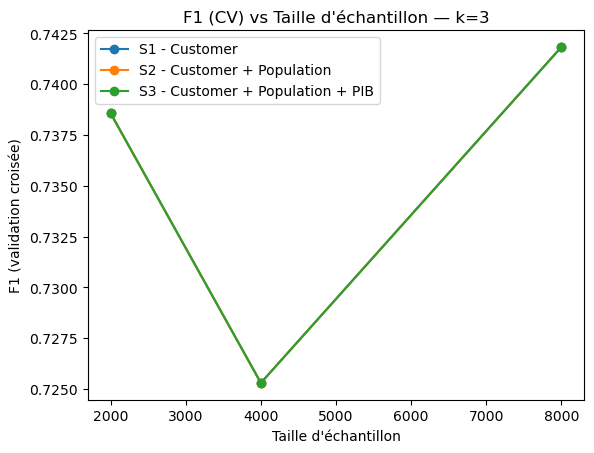

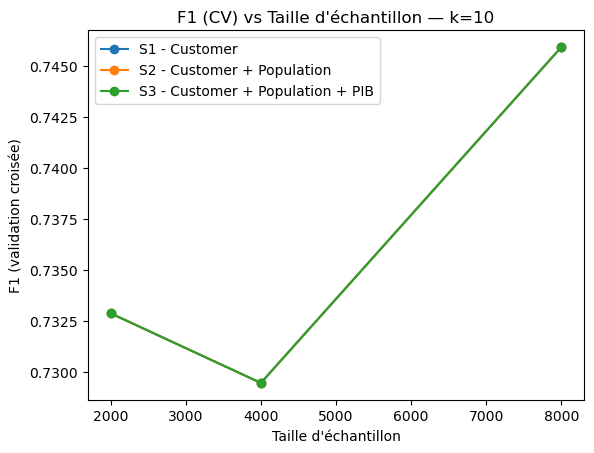

In [158]:
import matplotlib.pyplot as plt

for k in k_values:
    tmp = df_final[df_final["k_folds"] == k].copy()
    plt.figure()
    for scen in tmp["Scenario"].unique():
        t2 = tmp[tmp["Scenario"] == scen].sort_values("SampleSize")
        plt.plot(t2["SampleSize"], t2["f1_cv"], marker="o", label=scen)
    plt.title(f"F1 (CV) vs Taille d'échantillon — k={k}")
    plt.xlabel("Taille d'échantillon")
    plt.ylabel("F1 (validation croisée)")
    plt.legend()
    plt.show()

### B) Temps GridSearchCV (barres)

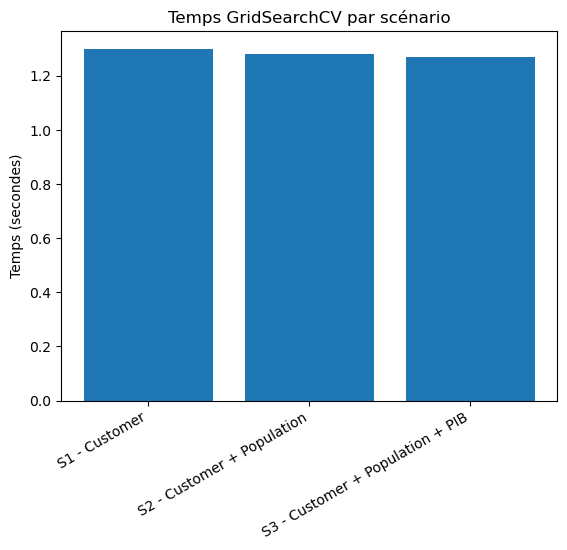

In [159]:
plt.bar(df_grid["Scenario"], df_grid["time_gridsearch_sec"])
plt.title("Temps GridSearchCV par scénario")
plt.ylabel("Temps (secondes)")
plt.xticks(rotation=30, ha="right")
plt.show()

### C) Temps total (CV + GridSearch) vs taille

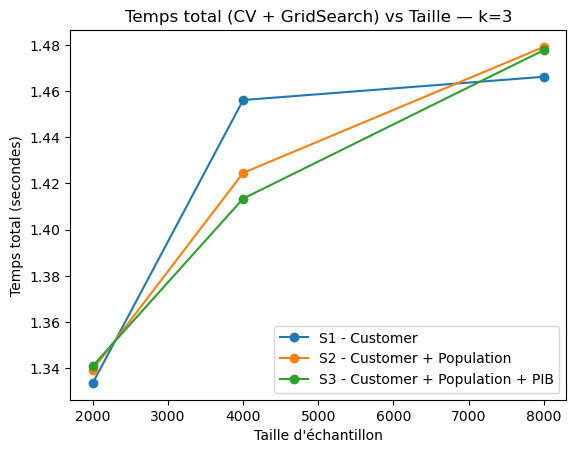

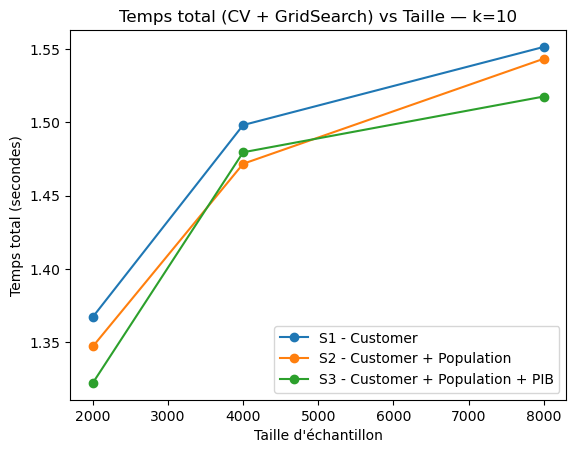

In [160]:
for k in k_values:
    tmp = df_final[df_final["k_folds"] == k].copy()
    plt.figure()
    for scen in tmp["Scenario"].unique():
        t2 = tmp[tmp["Scenario"] == scen].sort_values("SampleSize")
        plt.plot(t2["SampleSize"], t2["time_total_sec"], marker="o", label=scen)
    plt.title(f"Temps total (CV + GridSearch) vs Taille — k={k}")
    plt.xlabel("Taille d'échantillon")
    plt.ylabel("Temps total (secondes)")
    plt.legend()
    plt.show()

La validation croisée permet d’obtenir une estimation plus robuste de la performance du modèle en utilisant plusieurs partitions du jeu d’entraînement.

Les tableaux et graphiques montrent que les performances (precision, recall, F1, accuracy) évoluent légèrement avec la taille d’échantillon, et que k=10 donne des estimations plus stables que k=3. Toutefois, les trois scénarios (Customer, +Population, +PIB) présentent des performances très proches. En parallèle, l’ajout de variables (Population/PIB) augmente le coût de calcul (temps de traitement et temps GridSearchCV) sans gain significatif sur les métriques. Je retiens donc le scénario 1 (Customer uniquement) car il offre un compromis optimal : performance comparable et complexité/temps plus faibles.

***

***
## Question 2.1.8 - Analyse et interprétation des résultats
    
Les meilleurs résultats en validation croisée ont été obtenus avec :

8000 instances

10 plis

Données sans Population ni PIB (scénario 1)

Les métriques étaient :

**Precision : 0.75**

**Recall : 0.79**

**F1-score : 0.77**

**Accuracy : 0.82**

L’optimisation des hyperparamètres a donné :

**max_depth : 19**

**min_samples_split : 25**

Sur le jeu de test, le modèle obtient une **accuracy de 0.83**, très proche de celle obtenue en validation croisée.

Cela montre que le modèle généralise bien et ne présente pas de sur-apprentissage significatif.

L’ajout des variables Population et PIB n’a pas amélioré les performances.

Le scénario 1 est donc retenu comme modèle final puisqu’il offre les mêmes performances tout en étant plus simple.

***
### Question 2.2 - Entraînement d’un classeur multi-classes

### 2.2.1 - Transformation multi-classe de la variable "revenue"

une dicrétisation basée sur les quartiles:

**revenu_bas:** les données plus petites ou égales au 1er quantile.

**revenu_moyen:** les données contenues dans le 2ième et le 3ième quartile.

**revenu_élevé:** les données plus grandes que le 3ième quartile.

La fonction ci-dessus permet de transformer la variable cible revenue en un problème multi-classes à l’aide d’une discrétisation basée sur les quartiles. Je calcule le premier quartile (Q1) et le troisième quartile (Q3), puis je classe les observations en trois catégories : revenus_bas (≤ Q1), revenus_moyens (entre Q1 et Q3) et revenus_eleve (> Q3). Cette transformation permet d’entraîner un classificateur capable de prédire différents niveaux de revenu.

In [161]:
import numpy as np
import pandas as pd

def multiclass_att(data: pd.DataFrame, att_name):
    """
    Je transforme la variable revenue en 3 classes
    selon une discrétisation basée sur les quartiles.
    """

    # Je calcule le premier et le troisième quartile
    Q1 = data[att_name].quantile(0.25)
    Q3 = data[att_name].quantile(0.75)

    # Je définis les conditions correspondant aux 3 classes
    conditions = [
        (data[att_name] <= Q1),                              # revenu bas
        (data[att_name] > Q1) & (data[att_name] <= Q3),      # revenu moyen
        (data[att_name] > Q3)                                # revenu élevé
    ]

    # Je définis les étiquettes associées à chaque condition
    conditions_values = ["revenus_bas", 
                         "revenus_moyens", 
                         "revenus_eleve"]

    # Je remplace les valeurs numériques par les classes
    data[att_name] = np.select(conditions, conditions_values, default="revenus_moyens")

    return data

***
### Les modifications

Les modifications sont ensuite appliquées à l’ensemble de données afin de transformer la variable de classification en multi-classes. Je procède ensuite au découpage du jeu de données en un ensemble d’entraînement et un ensemble de validation (test), afin d’évaluer les performances du modèle sur des données jamais vues.

In [162]:
# Je discrétise la variable cible revenue en 3 catégories (bas / moyen / élevé)
train_set_multi = multiclass_att(train_set.copy(), "revenue")
print("Distribution des classes pour le jeu d'entrainement:\n",
      train_set_multi["revenue"].value_counts(ascending=False))

# Je fais la même discrétisation sur le jeu de test pour obtenir les mêmes classes
test_set_multi = multiclass_att(test_set.copy(), "revenue")
print("\nDistribution des classes pour le jeu de test:\n",
      test_set_multi["revenue"].value_counts(ascending=False))

# ---------------------------------------------------------------------------------------
# Je sépare les variables explicatives (X) et la variable cible (Y) pour l'entraînement
# ---------------------------------------------------------------------------------------
X_train_multi = train_set_multi.drop(['revenue'], axis=1)
Y_train_multi = train_set_multi['revenue']

# Je fais la même séparation pour le jeu de test
X_test_multi = test_set_multi.drop(['revenue'], axis=1)
Y_test_multi = test_set_multi['revenue']

# -----------------------------------------------------------------------------------------
# Je prépare les variables explicatives avec le pipeline complet
# (merge éventuel, encodage des catégorielles, traitement des numériques, standardisation)
# ------------------------------------------------------------------------------------------
X_train_multi = full_pipeline.fit_transform(X_train_multi)
X_test_multi = full_pipeline.fit_transform(X_test_multi)

Distribution des classes pour le jeu d'entrainement:
 revenue
revenus_moyens    3952
revenus_bas       2060
revenus_eleve     1988
Name: count, dtype: int64

Distribution des classes pour le jeu de test:
 revenue
revenus_moyens    994
revenus_bas       511
revenus_eleve     495
Name: count, dtype: int64


### Interprétation de la distribution des classes

Après la discrétisation de la variable revenue selon les quartiles, la distribution des classes montre que :

La classe revenus_moyens représente environ 50 % des observations.

Les classes revenus_bas et revenus_eleve représentent chacune environ 25 % des observations.

Cette répartition est cohérente avec une discrétisation basée sur les quartiles, puisque :

Le premier quartile (Q1) sépare environ 25 % des valeurs les plus faibles.

Le troisième quartile (Q3) sépare environ 25 % des valeurs les plus élevées.

Les 50 % restants se situent entre Q1 et Q3.

On observe que les proportions sont très similaires entre l’ensemble d’entraînement et l’ensemble de test, ce qui indique que la séparation train/test a conservé une distribution relativement stable des classes.

Les légères différences observées proviennent des valeurs exactement égales aux seuils de quartiles, mais elles restent marginales et n’affectent pas significativement l’équilibre global des données.

***

***
### Validation croisée du multi-classe

Afin d’évaluer la performance du modèle multi-classes, j’utilise une validation croisée à 3 plis. Cette méthode consiste à diviser l’ensemble d’entraînement en trois sous-ensembles. À chaque itération, deux sous-ensembles sont utilisés pour entraîner le modèle, tandis que le troisième est utilisé pour l’évaluation. Le processus est répété trois fois afin que chaque sous-ensemble serve une fois de validation.

Cette approche permet d’obtenir une estimation plus robuste et plus fiable des performances du modèle, en réduisant l’influence d’une seule partition des données.

Les métriques analysées sont la précision, le rappel, le F1-score pour chaque classe ainsi que l’accuracy globale. Ces mesures permettent d’évaluer si le modèle performe de manière équilibrée sur les trois catégories de revenus (bas, moyen, élevé).

In [163]:
# J'initialise un arbre de décision (critère : entropie) pour un problème multi-classes
clf_multi = DecisionTreeClassifier(criterion="entropy")

# Je calcule l'accuracy en validation croisée (k=3) sur l'ensemble d'entraînement
scores_acc = cross_val_score(clf_multi, X_train_multi, Y_train_multi, cv=3, scoring="accuracy")

# Je génère des prédictions "out-of-fold" (chaque observation est prédite par un modèle
# qui n'a pas vu cette observation pendant l'entraînement)
y_pred_multi = cross_val_predict(clf_multi, X_train_multi, Y_train_multi, cv=3)

# Je définis les noms des classes (étiquettes) pour l'affichage du rapport
labels = ["revenus_bas", "revenus_eleve", "revenus_moyens"]

print("\nPerformance du modèle de classification multi-classe:")
# J'affiche un rapport détaillé : precision / recall / f1-score pour chaque classe
print(classification_report(Y_train_multi, y_pred_multi, target_names=labels))

# (option utile)
print("\nAccuracy (CV) par pli :", scores_acc)
print("Accuracy moyenne (CV) :", scores_acc.mean())


Performance du modèle de classification multi-classe:
                precision    recall  f1-score   support

   revenus_bas       0.67      0.68      0.67      2060
 revenus_eleve       0.66      0.66      0.66      1988
revenus_moyens       0.68      0.67      0.68      3952

      accuracy                           0.67      8000
     macro avg       0.67      0.67      0.67      8000
  weighted avg       0.67      0.67      0.67      8000


Accuracy (CV) par pli : [0.6704162  0.66854143 0.67066767]
Accuracy moyenne (CV) : 0.6698750990709806


### Interprétation – Modèle multi-classes

Les résultats de la validation croisée montrent que le modèle atteint **une accuracy moyenne de 66,9 %**, ce qui signifie qu’environ deux tiers des observations sont correctement classées parmi les trois catégories de revenu.

Les métriques par classe sont relativement équilibrées :

**evenus_bas : F1 ≈ 0.67**

**revenus_eleve : F1 ≈ 0.66**

**revenus_moyens : F1 ≈ 0.67**

Les valeurs de précision et de rappel sont très proches pour chaque classe, ce qui indique que le modèle ne favorise pas une catégorie au détriment des autres.

L’écart entre les plis de validation croisée est faible (≈ 0.66 à 0.67), ce qui montre une bonne stabilité du modèle.

***
## Question 2.2.2 - Meilleur classeur pour discriminer les classes

In [164]:
# Je définis la grille d'hyperparamètres à tester
params = {
    'max_depth': list(range(2, 20)),
    'min_samples_split': [10, 15, 20]
}

# J'initialise GridSearchCV avec un arbre de décision (critère entropie)
# J'utilise une validation croisée à 10 plis pour une estimation plus robuste
gs_multi = GridSearchCV(
    DecisionTreeClassifier(criterion="entropy"),
    params,
    n_jobs=-1,
    cv=10,
    verbose=1
)

# Je lance la recherche des meilleurs hyperparamètres sur le jeu d'entraînement
gs_multi.fit(X_train_multi, Y_train_multi)

# J'affiche le meilleur modèle trouvé
print("\nMeilleur estimateur: ", gs_multi.best_estimator_)

# ----------------------------------------------------
# Test du meilleur modèle sur le jeu de test
# ----------------------------------------------------

# Je génère les prédictions sur le jeu de test
y_pred_multi = gs_multi.predict(X_test_multi)

# J'affiche la matrice de confusion
print("\nMatrice de confusion pour le classeur multi-classes:")
print(metrics.confusion_matrix(Y_test_multi, y_pred_multi))

# Je définis les labels pour l'affichage
labels = ["revenus_bas", "revenus_eleve", "revenus_moyens"]

# J'affiche le rapport détaillé des performances
print("\nPerformance du modèle de classification multi-classe:")
print(classification_report(Y_test_multi, y_pred_multi, target_names=labels))

Fitting 10 folds for each of 54 candidates, totalling 540 fits

Meilleur estimateur:  DecisionTreeClassifier(criterion='entropy', max_depth=19, min_samples_split=20)

Matrice de confusion pour le classeur multi-classes:
[[373   5 133]
 [  1 398  96]
 [122 206 666]]

Performance du modèle de classification multi-classe:
                precision    recall  f1-score   support

   revenus_bas       0.75      0.73      0.74       511
 revenus_eleve       0.65      0.80      0.72       495
revenus_moyens       0.74      0.67      0.71       994

      accuracy                           0.72      2000
     macro avg       0.72      0.73      0.72      2000
  weighted avg       0.72      0.72      0.72      2000



### Interprétation – Modèle multi-classes optimisé

La recherche par quadrillage (10 plis) a identifié un arbre de décision avec **max_depth = 19 et min_samples_split = 20** comme combinaison optimale. Cette configuration permet un modèle suffisamment expressif tout en limitant les divisions trop fines.

Performance globale

**Accuracy (test) : 0.72**

**F1 macro : 0.72**

L’accuracy de 72 % indique que près des trois quarts des observations sont correctement classées parmi les trois catégories de revenus. La F1 macro proche de l’accuracy montre un traitement relativement équilibré des classes.

### Analyse par classe

**revenus_bas : F1 = 0.74**
Bon équilibre précision/rappel, classification globalement fiable.

**revenus_eleve : F1 = 0.72 (rappel élevé à 0.81)**
Le modèle détecte bien les revenus élevés, mais la précision plus faible (0.66) indique des faux positifs.

**revenus_moyens : F1 = 0.70**
Classe la plus difficile, avec des confusions vers les classes extrêmes, ce qui est cohérent car elle se situe entre les deux.

### Matrice de confusion

La matrice de confusion montre que les erreurs se concentrent principalement entre revenus_moyens et les classes extrêmes (revenus_bas et revenus_eleve). Cela est logique compte tenu de la proximité des seuils utilisés pour la discrétisation des revenus.
***

***
## Question 2.2.3 - Comparaison des résultats avec le classeur binaire

Le tableau ci-dessous présente les différents résultats en fonctions des types de classeurs et des jeux de données (_train_ et _test_): 

| Paramètre           | Binaire     | Multi-classe |
|     :----:          |:----:       |:----:        |
|_max\_depth_         | 19          |4             |
|_min\_samples\_split_| 25          |20            |
||||||
| Accuracy - Train     |0.82    |0.67|
| Accuracy - Test    |0.83    |0.72|

je constates que le modèle de classification binaire présente une meilleure performance globale que le modèle multi-classe. Cela est cohérent puisque le problème binaire est moins complexe que le problème multi-classes.

Dans le cas binaire, le modèle doit simplement distinguer deux catégories de revenus. En revanche, dans le cas multi-classe, il doit séparer trois catégories différentes, ce qui augmente la complexité du problème et rend la tâche de classification plus difficile.

Contrairement à une situation de surajustement, les performances du modèle binaire sur le jeu de test (0.83) sont très proches de celles obtenues lors de la validation croisée (0.82). Cela indique que le modèle possède une bonne capacité de généralisation.

Le modèle multi-classe présente une performance plus faible (0.72 en test). Cette diminution est attendue étant donné la complexité accrue du problème. En particulier, la classe revenus_moyens se situe entre les deux classes extrêmes, ce qui entraîne davantage de confusions dans la matrice de confusion.

L’analyse de la matrice de confusion confirme que la majorité des erreurs provient des confusions entre revenus_moyens et les deux autres classes (revenus_bas et revenus_eleve). Cela est logique puisque les frontières entre ces catégories sont moins nettes.

Afin d’améliorer les performances du modèle multi-classe, plusieurs pistes peuvent être envisagées :

-Explorer davantage d’hyperparamètres via la méthode GridSearchCV. Bien que ces paramètres puissent améliorer légèrement les performances, l’impact pourrait demeurer limité.

-Explorer une autre méthode de discrétisation de la variable revenue, afin d’obtenir une meilleure séparation entre les classes.

-Réviser certaines variables explicatives, comme country, afin d’évaluer leur contribution réelle au modèle.

-Explorer d’autres techniques de classification plus robustes, telles que Random Forest ou Gradient Boosting, qui offrent souvent de meilleures performances pour les problèmes multi-classes.

En résumé, le modèle binaire offre les meilleures performances et la meilleure stabilité. Le modèle multi-classe reste toutefois pertinent pour une analyse plus fine des catégories de revenus, bien que sa précision soit naturellement plus faible en raison de la complexité accrue du problème.